# TFT (Temporal Fusion Transformer): model experiment



In [ ]:

import importlib.util, os, subprocess, sys
from pathlib import Path

IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/ML_FINAL_PROJECT")
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data" / "train.csv.zip").exists())

PACKAGES = {"darts": "u8darts[torch]", "optuna": "optuna", "mlflow": "mlflow"}
installed = [pkg for mod, pkg in PACKAGES.items()
             if importlib.util.find_spec(mod) is None]
for pkg in installed:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

if installed and IN_COLAB:

    print("Installed:", installed, flush=True)
    print("Restarting the Colab runtime now. Run all cells again.", flush=True)
    os.kill(os.getpid(), 9)
elif installed:
    print("Installed:", installed)
    print("If the imports below fail, restart the kernel and run again.")

sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Installed: ['u8darts[torch]', 'optuna', 'mlflow']
If the imports below fail, restart the kernel and run again.
ROOT = /Users/zurabi/Downloads/ML_FINAL_PROJECT_1



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
import json
import tempfile

import numpy as np
import pandas as pd
import mlflow
import torch

from src.ts_pipeline import GlobalDartsPipeline, DartsPipelinePyfunc

torch.set_float32_matmul_precision("medium")
DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("torch device Lightning will use:", DEVICE)

from src.preprocessing import Cleaner
from src.validation import FOLDS, evaluate, wmae
from src.experiment_utils import setup_mlflow, run_stage, log_table
from src import ts_data

train    = pd.read_csv(ROOT / "data/train.csv.zip")
test     = pd.read_csv(ROOT / "data/test.csv.zip")
features = pd.read_csv(ROOT / "data/features.csv.zip")
stores   = pd.read_csv(ROOT / "data/stores.csv")

DAGSHUB_REPO = "ZukaCS/ML_FINAL_PROJECT"
print("tracking:", setup_mlflow(ROOT, dagshub_repo=DAGSHUB_REPO))
print("train", train.shape, "| test", test.shape)

/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch device Lightning will use: mps


/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


tracking: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow
train (421570, 5) | test (115064, 4)


In [ ]:
_clean = Cleaner(stores, features).fit_transform(train)
_series, _, _report = ts_data.build_target_series(_clean)


_rows = _clean.sample(500, random_state=0)
for _, _r in _rows.iterrows():
    _ts = _series[(_r["Store"], _r["Dept"])]
    _pos = _ts.time_index.get_loc(pd.Timestamp(_r["Date"]))
    assert np.isclose(_ts.values(copy=False).ravel()[_pos], _r["Weekly_Sales"],
                      rtol=1e-4, atol=1.0)

# (b) common end date after tail padding
assert all(_s.end_time() == _clean["Date"].max() for _s in _series.values())

# (c) covariates reach the end of the test period, no NaN
_covs = ts_data.build_covariates(features, "full")
assert _covs[1].end_time() >= pd.to_datetime(test["Date"]).max()
assert not np.isnan(_covs[1].values()).any()

print("sanity checks passed |", _report)

sanity checks passed | {'n_series': 3331, 'n_weeks_common_grid': 143, 'n_gap_weeks_filled': 27667, 'n_tail_padded_series': 372, 'n_tail_padded_weeks': 12816, 'n_late_start_series': 376}


## 1. Pipeline factory



In [ ]:
from darts.models import TFTModel

PL_KWARGS = {"accelerator": "auto", "enable_progress_bar": False,
             "enable_model_summary": False, "logger": False}

# likelihood stays at the Darts default QuantileRegression; the pipeline
# predicts the quantile parameters and keeps the deterministic q0.50 median
# (num_samples=1 sampling would be stochastic). Store/Dept use categorical
# embeddings: nominal ids must not enter the network as scaled numbers.
TFT_DEFAULT = dict(
    input_chunk_length=52, output_chunk_length=13,
    hidden_size=32, lstm_layers=1, num_attention_heads=4,
    full_attention=False, dropout=0.1, hidden_continuous_size=8,
    add_relative_index=False,
    categorical_embedding_sizes={"static_store": 45, "static_dept": 99},
    n_epochs=15, batch_size=256, optimizer_kwargs={"lr": 1e-3},
    random_state=42, pl_trainer_kwargs=PL_KWARGS)

PIPE_DEFAULT = dict(covariate_preset="full", log_target=False,
                    scale=True, use_statics=True, max_samples_per_ts=10,
                    holiday_weight=5.0)   # 5x holiday weight in the loss

def make_pipeline(model_params=None, pipe_params=None):
    mp = {**TFT_DEFAULT, **(model_params or {})}
    pp = {**PIPE_DEFAULT, **(pipe_params or {})}
    return GlobalDartsPipeline(
        stores, features,
        model_factory=lambda: TFTModel(**mp),
        input_chunk_length=mp["input_chunk_length"],
        output_chunk_length=mp["output_chunk_length"], **pp)

def full_config(model_params=None, pipe_params=None):
    return {**TFT_DEFAULT, **(model_params or {}),
            "likelihood": "QuantileRegression_darts_default",
            **PIPE_DEFAULT, **(pipe_params or {})}

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## 2. Stage: `TFT_Preprocessing`



In [ ]:
mlflow.set_experiment("TFT_Training")
_clean_full = Cleaner(stores, features).fit_transform(train)
_, _, prep_report = ts_data.build_target_series(_clean_full)

with mlflow.start_run(run_name="TFT_Preprocessing"):
    mlflow.set_tag("stage", "Preprocessing")
    mlflow.log_params({
        "clip_negatives": True,
        "markdown_impute": "zero",
        "cpi_unemp_impute": "ffill_per_store",
        "series_unit": "Store_x_Dept_weekly",
        "reindex_freq": "W-FRI",
        "gap_fill_value": 0,
        "tail_pad_to_common_end_value": 0,
        "late_start_series": "kept_without_backfill",
        "target_transform": "none_quantile_loss_on_minmax_scale",
        "per_series_scaling": "minmax_fit_in_pipeline_fit",
        "loss_alignment": "quantile_loss_with_5x_holiday_sample_weight_median_matches_WMAE",
        "covariate_scaling": "minmax_over_known_full_range",
        "fallback_predictor": "seasonal_naive_dept_median",
    })
    mlflow.log_metrics({k: float(v) for k, v in prep_report.items()})
prep_report

🏃 View run TFT_Preprocessing at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/40192ee9f4794a0c84a4b3b918a5f7b9
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6


{'n_series': 3331,
 'n_weeks_common_grid': 143,
 'n_gap_weeks_filled': 27667,
 'n_tail_padded_series': 372,
 'n_tail_padded_weeks': 12816,
 'n_late_start_series': 376}

## 3. Stage: `TFT_Feature_Engineering`



In [ ]:
STATIC_COLS = ["static_store", "static_dept", "static_type", "static_size"]

mlflow.set_experiment("TFT_Training")
with mlflow.start_run(run_name="TFT_Feature_Engineering"):
    mlflow.set_tag("stage", "Feature_Engineering")
    mlflow.log_params({
        "future_covariates_built": json.dumps(ts_data.PRESET_COLUMNS["full"]),
        "columns_added": json.dumps(ts_data.CALENDAR_HOLIDAY_COLS),
        "columns_renamed": json.dumps({
            "MarkDown1..5": "markdown1..5", "Temperature": "temperature",
            "Fuel_Price": "fuel_price", "CPI": "cpi",
            "Unemployment": "unemployment"}),
        "static_covariates_built": json.dumps(STATIC_COLS),
        "static_encoding": ("store/dept: integer codes -> TFT categorical "
                            "embeddings; type: ordinal; size: minmax"),
    })
    log_table(ts_data.covariate_table("full", static_cols=STATIC_COLS),
              "covariate_columns.csv")
print("feature engineering logged")

🏃 View run TFT_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/75c59834a36b476683f9bc15c9c73ea1
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
feature engineering logged


## 4. Stage: `TFT_Feature_Selection`

TFT is the covariate-hungry architecture, so the full set is the default and
the leaner calendar/holiday preset is kept in the CV space as a check that the
macro block actually earns its place.

In [ ]:
CANDIDATE_PRESETS = ["calendar_holiday", "full"]

mlflow.set_experiment("TFT_Training")
with mlflow.start_run(run_name="TFT_Feature_Selection"):
    mlflow.set_tag("stage", "Feature_Selection")
    mlflow.log_params({
        "target_columns_used": json.dumps(["Store", "Dept", "Date", "Weekly_Sales"]),
        "selected_static_covariates": json.dumps(STATIC_COLS),
        "candidate_future_covariate_presets": json.dumps(CANDIDATE_PRESETS),
        "decided_by": "TFT_CV covariate_preset hyperparameter",
        "rationale": ("TFT has variable-selection networks built for wide "
                      "covariate sets; full set is the default, the lean "
                      "preset stays in CV as a control"),
    })
    for _preset in CANDIDATE_PRESETS:
        log_table(ts_data.covariate_table(_preset, static_cols=STATIC_COLS),
                  f"candidate_{_preset}.csv")
print("feature selection logged")

🏃 View run TFT_Feature_Selection at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/97f4dc5ac33b4a88984054b8f194a86d
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
feature selection logged


## 5. Stage: `TFT_CV` : hyperparameter tuning

Optuna TPE, 20 trials x 3 folds

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=15` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_lea

🏃 View run trial_000 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/44cf1597d43747c596ebc8a417b7708f
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
trial 000: wmae_mean=3,388


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=15` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_lea

🏃 View run trial_001 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/00742300fd7c402980caf55f0a852bfd
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
trial 001: wmae_mean=3,195


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=15` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_lea

...

🏃 View run trial_010 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/174dfac0127a4a8d8113f21c6251b865
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
trial 010: wmae_mean=3,436


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=15` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_lea

🏃 View run trial_011 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/0656be90ca2747b783bc76de92fc1b76
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
trial 011: wmae_mean=3,359


/var/folders/6_/q84br0gj3cjb50yz09jrcp_40000gn/T/ipykernel_77005/2128103191.py:56: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_optimization_history(study).figure,
/var/folders/6_/q84br0gj3cjb50yz09jrcp_40000gn/T/ipykernel_77005/2128103191.py:58: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_param_importances(study).figure,


🏃 View run TFT_CV at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/a1698b42286b4691bcc99c375c4fce19
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
best wmae_mean: 3193.0
best params: {'chunk_choice': 0, 'hidden_size': 32, 'lstm_layers': 2, 'num_attention_heads': 4, 'full_attention': True, 'dropout': 0.1623422152178822, 'hidden_continuous_size': 16, 'batch_size': 256, 'lr': 0.0029792217348362585, 'covariate_preset': 'calendar_holiday'}


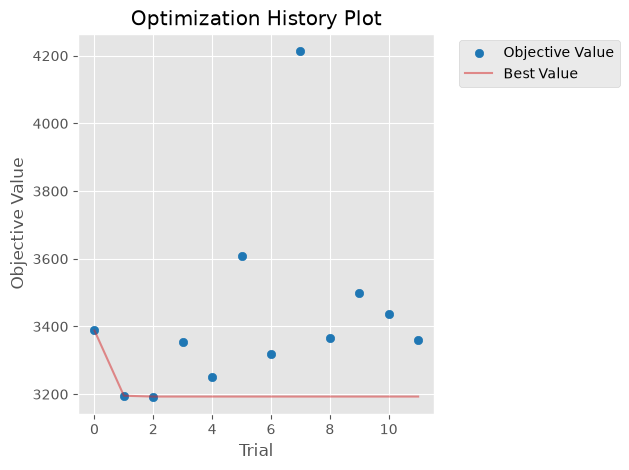

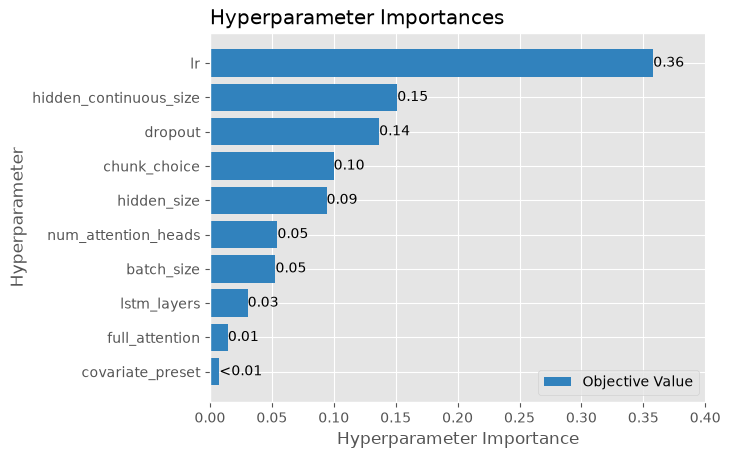

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 12
CHUNKS = [(52, 13), (65, 13)]

def sample_params(trial):
    ci, co = CHUNKS[trial.suggest_int("chunk_choice", 0, len(CHUNKS) - 1)]
    model_params = dict(
        input_chunk_length=ci, output_chunk_length=co,
        hidden_size=trial.suggest_categorical("hidden_size", [16, 32, 64]),
        lstm_layers=trial.suggest_categorical("lstm_layers", [1, 2]),
        num_attention_heads=trial.suggest_categorical("num_attention_heads", [1, 4]),
        full_attention=trial.suggest_categorical("full_attention", [False, True]),
        dropout=trial.suggest_float("dropout", 0.1, 0.3),
        hidden_continuous_size=trial.suggest_categorical(
            "hidden_continuous_size", [8, 16]),
        batch_size=trial.suggest_categorical("batch_size", [128, 256]),
        optimizer_kwargs={"lr": trial.suggest_float("lr", 5e-4, 5e-3, log=True)})
    pipe_params = dict(covariate_preset=trial.suggest_categorical(
        "covariate_preset", ["calendar_holiday", "full"]))
    return model_params, pipe_params

mlflow.set_experiment("TFT_Training")
with mlflow.start_run(run_name="TFT_CV"):
    mlflow.set_tag("stage", "CV")
    mlflow.log_params({"n_trials": N_TRIALS, "search": "optuna_tpe_seed42",
                       "cv_scope": "all_series_3_rolling_folds"})

    def objective(trial):
        model_params, pipe_params = sample_params(trial)
        cfg = full_config(model_params, pipe_params)
        with mlflow.start_run(run_name=f"trial_{trial.number:03d}", nested=True):
            mlflow.log_params({k: str(v) for k, v in cfg.items()})
            metrics = evaluate(lambda: make_pipeline(model_params, pipe_params),
                               train)
            mlflow.log_metrics(metrics)
        print(f"trial {trial.number:03d}: wmae_mean={metrics['wmae_mean']:,.0f}")
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return metrics["wmae_mean"]

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS)

    BEST_MODEL_PARAMS, BEST_PIPE_PARAMS = sample_params(
        optuna.trial.FixedTrial(study.best_params))
    mlflow.log_metric("best_wmae_mean", study.best_value)
    mlflow.log_params({f"best_{k}": str(v) for k, v in study.best_params.items()})
    try:
        from optuna.visualization.matplotlib import (
            plot_optimization_history, plot_param_importances)
        mlflow.log_figure(plot_optimization_history(study).figure,
                          "cv_optimization_history.png")
        mlflow.log_figure(plot_param_importances(study).figure,
                          "cv_param_importances.png")
    except Exception as e:
        print("optuna plots skipped:", e)

print("best wmae_mean:", round(study.best_value, 1))
print("best params:", study.best_params)

## 6. Stage: `TFT_Final`

Re-score the winning config with the shared 3-fold CV, retrain it on **all**
training data, and log the whole pipeline as an MLflow pyfunc model. Create submission file as well.

In [ ]:
mlflow.set_experiment("TFT_Training")
with mlflow.start_run(run_name="TFT_Final") as final_run:
    mlflow.set_tag("stage", "Final")

    final_cfg = full_config(BEST_MODEL_PARAMS, BEST_PIPE_PARAMS)
    final_pipe = make_pipeline(BEST_MODEL_PARAMS, BEST_PIPE_PARAMS).fit(train)
    final_metrics = evaluate(lambda: make_pipeline(BEST_MODEL_PARAMS, BEST_PIPE_PARAMS), train)
    mlflow.log_params({k: str(v) for k, v in final_cfg.items()})
    mlflow.log_params({("pipe_" + k): str(v)
                       for k, v in final_pipe.get_params().items()})
    mlflow.log_metrics(final_metrics)

    # assignment requirement: the saved pipeline runs on the RAW test.csv
    preds = final_pipe.predict(test)
    assert len(preds) == len(test) and not np.isnan(preds).any()
    mlflow.log_metrics({"n_fallback_rows_test": final_pipe.last_fallback_rows_,
                       })

    with tempfile.TemporaryDirectory() as _td:
        _pipe_dir = Path(_td) / "pipeline"
        final_pipe.save(_pipe_dir)
        mlflow.pyfunc.log_model(
            name="model", python_model=DartsPipelinePyfunc(),
            artifacts={"pipeline_dir": str(_pipe_dir)},
            code_paths=[str(ROOT / "src")],
            input_example=test.head(5))

    sub = pd.DataFrame({
        "Id": test["Store"].astype(str) + "_" + test["Dept"].astype(str)
              + "_" + test["Date"].astype(str),
        "Weekly_Sales": preds,
    })
    (ROOT / "submissions").mkdir(exist_ok=True)
    sub_path = ROOT / "submissions" / "submission_tft.csv"
    sub.to_csv(sub_path, index=False)
    mlflow.log_artifact(str(sub_path))

print("final CV:", {k: round(v, 1) for k, v in final_metrics.items()})
print("run_id:", final_run.info.run_id)
sub.head()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=15` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/zurabi/Downloads/ML_FINAL_PROJECT_1/.venv1/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_lea

🏃 View run TFT_Final at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6/runs/53b50abce5534c49aabffb60fe375100
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/6
final CV: {'wmae_fold1': 4631.4, 'wmae_fold2': 2879.0, 'wmae_fold3': 2277.2, 'wmae_mean': 3262.5}
run_id: 53b50abce5534c49aabffb60fe375100


,Id,Weekly_Sales
0,1_1_2012-11-02,26963.028494
1,1_1_2012-11-09,28731.291539
2,1_1_2012-11-16,29359.784765
3,1_1_2012-11-23,29208.672930
4,1_1_2012-11-30,27616.252798
